In [30]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
from google.colab import files

uploaded = files.upload()

Saving airbnb_clean.csv to airbnb_clean (2).csv


In [32]:
df = pd.read_csv("airbnb_clean.csv")

/tmp/ipykernel_1706/765626769.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("airbnb_clean.csv")


Za analizu se koristi prethodno očišćeni skup podataka dobiven u fazi pripreme podataka.

In [33]:
df["neighbourhood_group"].value_counts()

,count
neighbourhood_group,
Manhattan,22245
Brooklyn,20331
Queens,6485
Bronx,1465
Staten Island,506
manhatan,1


In [34]:
df[df["neighbourhood_group"] == "manhatan"]

,id,name,host_id,host_identity_verified,host_name,neighbourhood_group,neighbourhood,lat,long,country,...,room_type,construction_year,price,service_fee,minimum_nights,number_of_reviews,reviews_per_month,review_rate_number,calculated_host_listings_count,availability_365
6,1011277,Chelsea Perfect,7.386253e+10,verified,Alberta,manhatan,Chelsea,40.74192,-73.99501,United States,...,Private room,2008.0,460.0,105.0,1.0,260.0,2.12,3.0,1.0,325.0


In [35]:
df["neighbourhood_group"] = df["neighbourhood_group"].replace(
    "manhatan",
    "Manhattan"
)

In [36]:
df.head()

,id,name,host_id,host_identity_verified,host_name,neighbourhood_group,neighbourhood,lat,long,country,...,room_type,construction_year,price,service_fee,minimum_nights,number_of_reviews,reviews_per_month,review_rate_number,calculated_host_listings_count,availability_365
0,1001254,Clean & quiet apt home by the park,8.001449e+10,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,Private room,2020.0,966.0,193.0,10.0,9.0,0.21,4.0,6.0,286.0
1,1002102,Skylit Midtown Castle,5.233517e+10,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,Entire home/apt,2007.0,142.0,28.0,30.0,45.0,0.38,4.0,2.0,228.0
2,1002755,NaN,8.509833e+10,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,Entire home/apt,2005.0,368.0,74.0,30.0,270.0,4.64,4.0,1.0,322.0
3,1004650,BlissArtsSpace!,6.130061e+10,NaN,Alberta,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,United States,...,Private room,2015.0,71.0,14.0,45.0,49.0,0.40,5.0,1.0,224.0
4,1006859,Cute & Cozy Lower East Side 1 bdrm,1.280143e+09,verified,Miranda,Manhattan,Chinatown,40.71344,-73.99037,United States,...,Entire home/apt,2004.0,319.0,64.0,1.0,160.0,1.33,3.0,4.0,1.0


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51071 entries, 0 to 51070
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              51071 non-null  object 
 1   name                            50913 non-null  object 
 2   host_id                         51049 non-null  float64
 3   host_identity_verified          50908 non-null  object 
 4   host_name                       50853 non-null  object 
 5   neighbourhood_group             51033 non-null  object 
 6   neighbourhood                   51044 non-null  object 
 7   lat                             51045 non-null  float64
 8   long                            51045 non-null  float64
 9   country                         50743 non-null  object 
 10  country_code                    51000 non-null  object 
 11  instant_bookable                51014 non-null  object 
 12  cancellation_policy             

In [38]:
df.describe()

,host_id,lat,long,construction_year,price,service_fee,minimum_nights,number_of_reviews,reviews_per_month,review_rate_number,calculated_host_listings_count,availability_365
count,5.104900e+04,51045.000000,51045.00000,50958.000000,51071.000000,51071.000000,51071.000000,51071.000000,51071.000000,51071.000000,51071.000000,51071.000000
mean,4.923543e+10,40.728609,-73.94957,2012.478845,525.931762,105.221065,8.483503,28.630279,1.295673,3.307356,8.712440,137.790135
std,2.853310e+10,0.056275,0.05032,5.773513,273.955826,54.825779,32.500701,52.056288,1.700432,1.268176,34.079304,129.216702
min,1.236005e+08,40.499790,-74.24984,2003.000000,50.000000,10.000000,1.000000,0.000000,0.010000,1.000000,1.000000,0.000000
25%,2.460424e+10,40.688930,-73.98294,2007.000000,288.000000,58.000000,2.000000,2.000000,0.290000,2.000000,1.000000,6.000000
50%,4.907810e+10,40.722830,-73.95464,2012.000000,527.000000,105.000000,3.000000,8.000000,0.770000,3.000000,1.000000,98.000000
75%,7.388642e+10,40.763110,-73.93245,2017.000000,762.000000,152.000000,5.000000,31.000000,1.740000,4.000000,3.000000,258.000000
max,9.876313e+10,40.916970,-73.70522,2022.000000,999.000000,239.000000,5645.000000,1024.000000,90.000000,5.000000,332.000000,365.000000


Prije detaljnije analize pregledani su osnovni statistički pokazatelji numeričkih atributa te struktura skupa podataka.

Na taj način dobiven je uvid u raspon vrijednosti, srednje vrijednosti te raspoložive atribute koji će se koristiti u daljnjoj analizi.

## Distribucija cijena smještaja

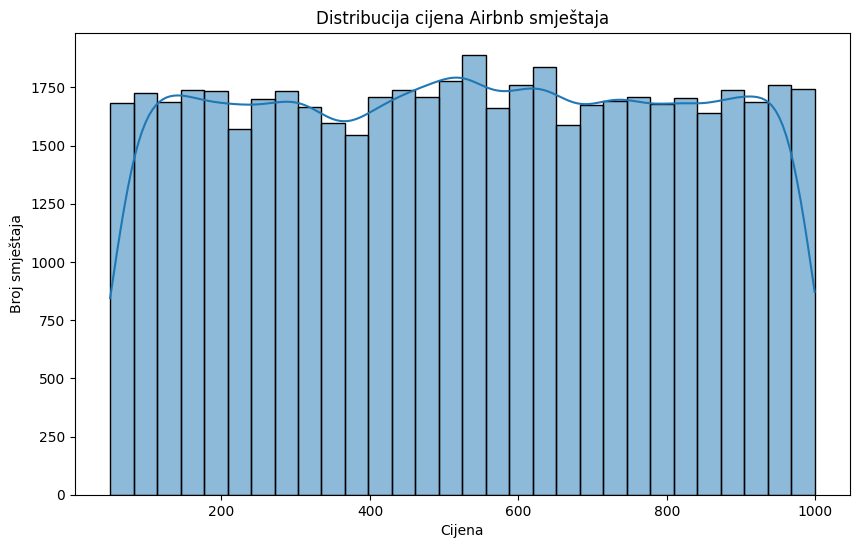

In [39]:
plt.figure(figsize=(10, 6))

sns.histplot(df["price"], bins=30, kde=True)

plt.title("Distribucija cijena Airbnb smještaja")
plt.xlabel("Cijena")
plt.ylabel("Broj smještaja")

plt.show()

Histogram prikazuje raspodjelu cijena Airbnb smještaja u promatranom skupu podataka.

Na temelju grafa može se uočiti u kojem se cjenovnom rasponu nalazi najveći broj oglasa te postoje li smještaji s izrazito visokim ili niskim cijenama.

Ovakva analiza važna je za razumijevanje strukture tržišta i kasnije modeliranje cijena.

## Analiza outliera u cijenama

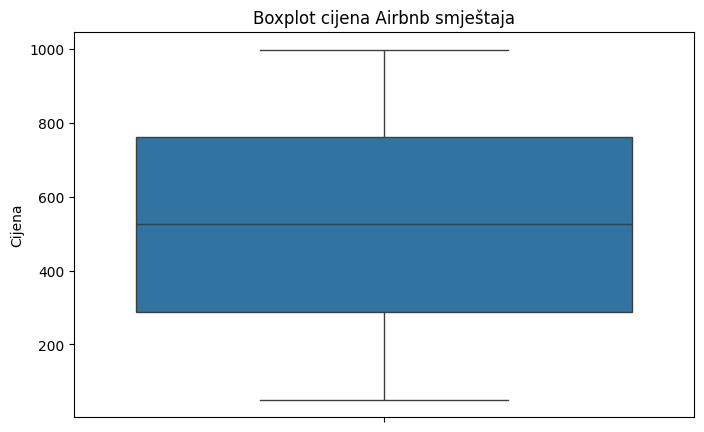

In [40]:
plt.figure(figsize=(8, 5))

sns.boxplot(y=df["price"])

plt.title("Boxplot cijena Airbnb smještaja")
plt.ylabel("Cijena")

plt.show()

Boxplot prikazuje medijan, kvartile i potencijalne outliere u atributu cijene.

Može se uočiti kolika je varijabilnost cijena te postoje li smještaji čije cijene značajno odstupaju od ostatka skupa podataka.

## Distribucija ocjena smještaja

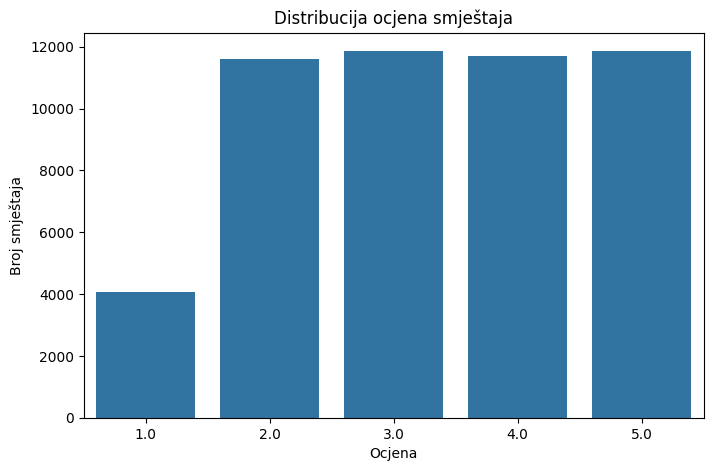

In [41]:
plt.figure(figsize=(8, 5))

sns.countplot(x="review_rate_number", data=df)

plt.title("Distribucija ocjena smještaja")
plt.xlabel("Ocjena")
plt.ylabel("Broj smještaja")

plt.show()

Prikazana je raspodjela ocjena koje su korisnici dodijelili smještajima.

Analiza ocjena omogućuje procjenu opće kvalitete smještaja te uvid u zadovoljstvo korisnika.

## Zastupljenost tipova smještaja

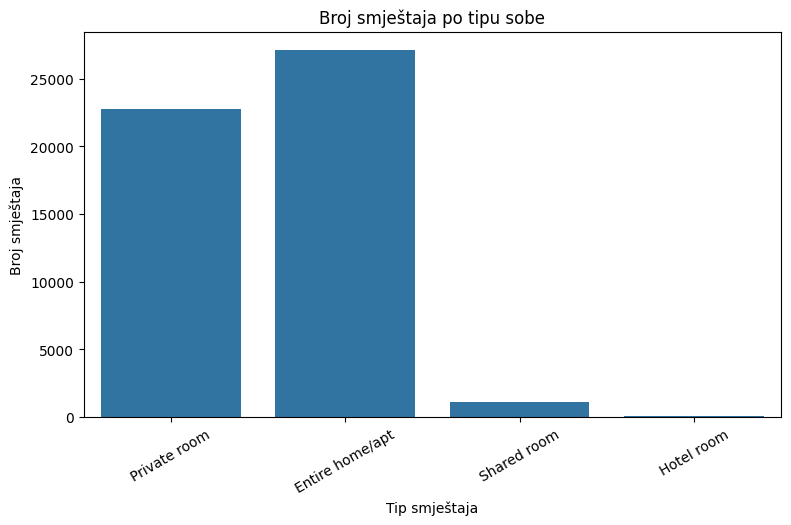

In [42]:
plt.figure(figsize=(9, 5))

sns.countplot(x="room_type", data=df)

plt.title("Broj smještaja po tipu sobe")
plt.xlabel("Tip smještaja")
plt.ylabel("Broj smještaja")

plt.xticks(rotation=30)

plt.show()

Graf prikazuje koliko je zastupljen svaki tip smještaja.

Dobiveni rezultati omogućuju uvid u strukturu Airbnb ponude te pokazuju koji su tipovi smještaja najčešći na tržištu.

## Usporedba cijena prema tipu smještaja

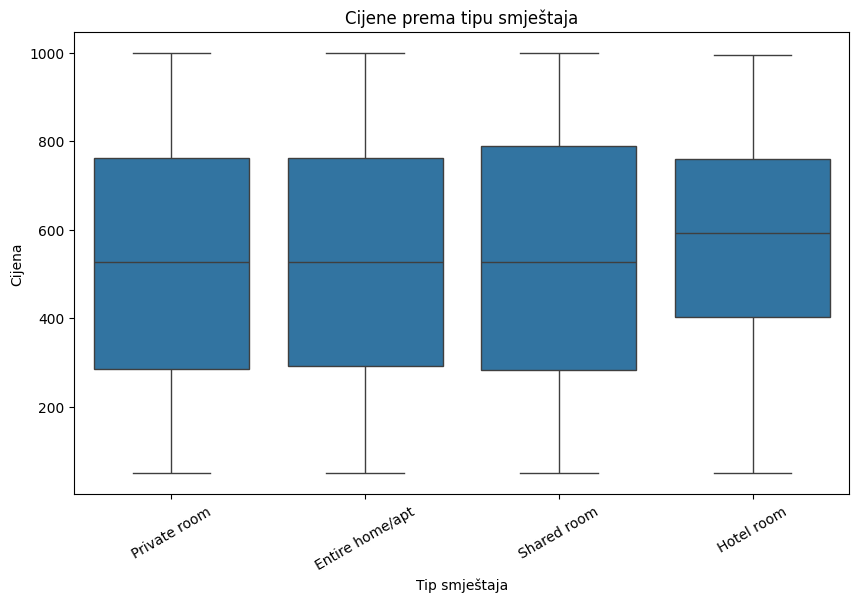

In [43]:
plt.figure(figsize=(10, 6))

sns.boxplot(x="room_type", y="price", data=df)

plt.title("Cijene prema tipu smještaja")
plt.xlabel("Tip smještaja")
plt.ylabel("Cijena")

plt.xticks(rotation=30)

plt.show()

Prikazana je raspodjela cijena za različite tipove smještaja.

Analiza omogućuje usporedbu cjenovnih razlika između cijelih apartmana, privatnih soba i ostalih tipova smještaja.

## Prostorna raspodjela oglasa

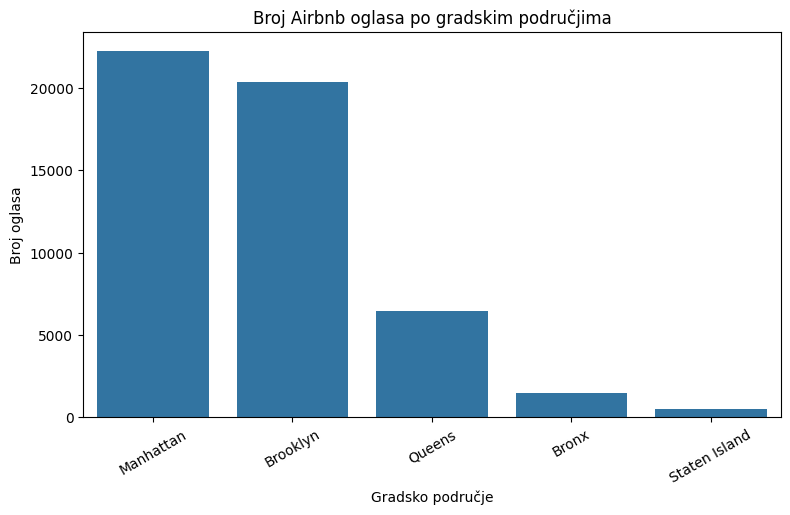

In [44]:
plt.figure(figsize=(9, 5))

sns.countplot(
    x="neighbourhood_group",
    data=df,
    order=df["neighbourhood_group"].value_counts().index
)

plt.title("Broj Airbnb oglasa po gradskim područjima")
plt.xlabel("Gradsko područje")
plt.ylabel("Broj oglasa")

plt.xticks(rotation=30)

plt.show()

Graf prikazuje broj Airbnb oglasa po gradskim područjima.

Rezultati pokazuju koja područja imaju najveću koncentraciju smještaja te gdje je Airbnb najzastupljeniji.

## Prosječna cijena prema gradskom području

In [45]:
avg_price_group = (
    df.groupby("neighbourhood_group")["price"]
    .mean()
    .sort_values(ascending=False)
)

avg_price_group

,price
neighbourhood_group,
Bronx,531.965870
Brooklyn,527.847425
Manhattan,525.044278
Queens,521.832845
Staten Island,519.883399


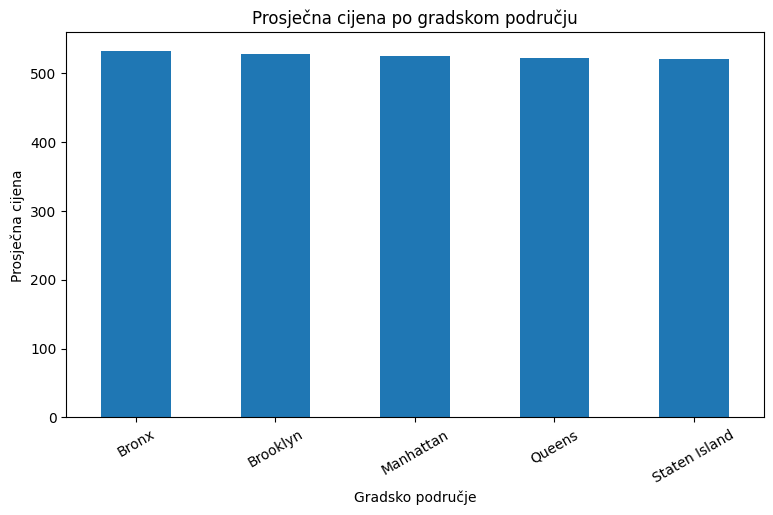

In [46]:
plt.figure(figsize=(9, 5))

avg_price_group.plot(kind="bar")

plt.title("Prosječna cijena po gradskom području")
plt.xlabel("Gradsko područje")
plt.ylabel("Prosječna cijena")

plt.xticks(rotation=30)

plt.show()

Prikazane su prosječne cijene smještaja u pojedinim gradskim područjima.

Ova analiza omogućuje usporedbu atraktivnosti i cjenovne razine različitih dijelova grada.

## Najzastupljeniji kvartovi

In [47]:
top_neighbourhoods = df["neighbourhood"].value_counts().head(10)

top_neighbourhoods

,count
neighbourhood,
Bedford-Stuyvesant,4028
Williamsburg,3795
Harlem,2740
Bushwick,2301
Hell's Kitchen,2061
Upper West Side,1946
Upper East Side,1823
Midtown,1814
East Village,1686


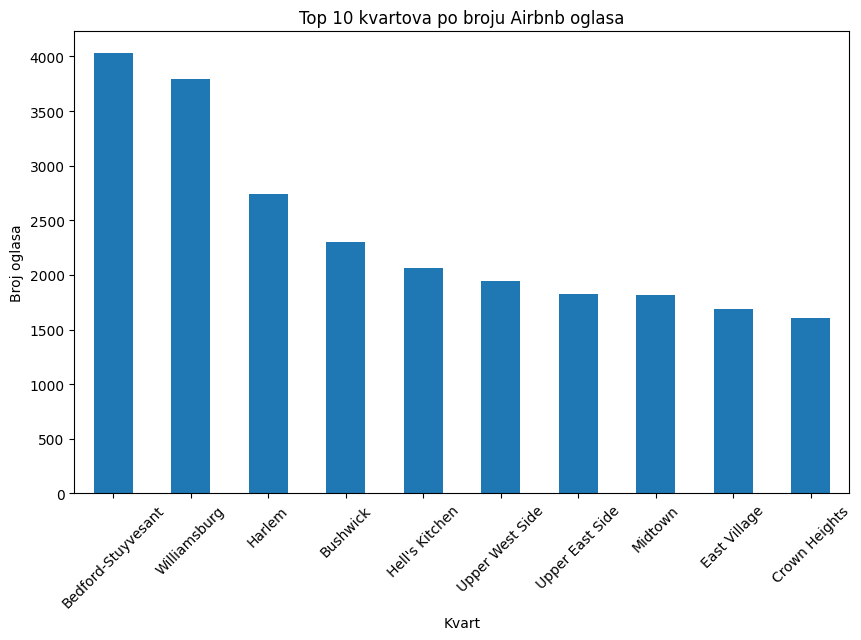

In [48]:
plt.figure(figsize=(10, 6))

top_neighbourhoods.plot(kind="bar")

plt.title("Top 10 kvartova po broju Airbnb oglasa")
plt.xlabel("Kvart")
plt.ylabel("Broj oglasa")

plt.xticks(rotation=45)

plt.show()

Prikazani su kvartovi s najvećim brojem Airbnb oglasa.

Rezultati pokazuju u kojim dijelovima grada je kratkoročni najam najrazvijeniji.

## Odnos cijene i broja recenzija

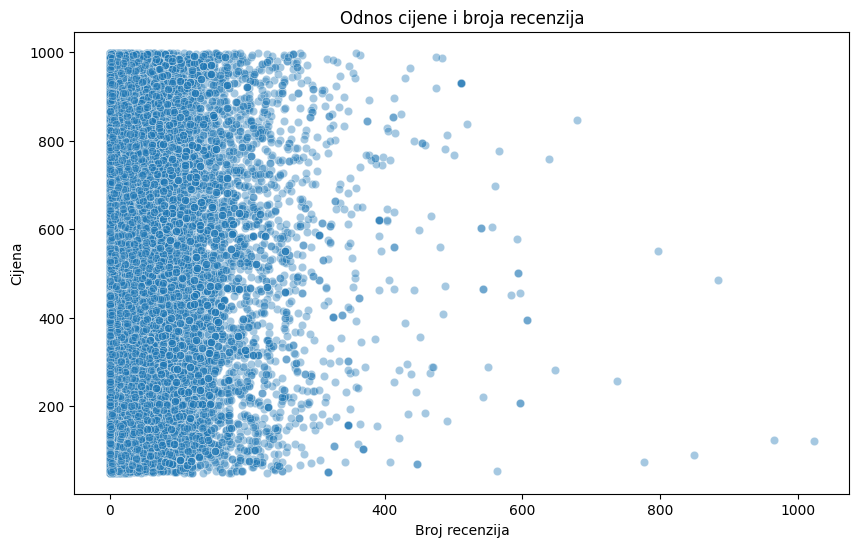

In [49]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x="number_of_reviews",
    y="price",
    data=df,
    alpha=0.4
)

plt.title("Odnos cijene i broja recenzija")
plt.xlabel("Broj recenzija")
plt.ylabel("Cijena")

plt.show()

Scatter graf prikazuje odnos između cijene smještaja i broja recenzija.

Na temelju prikaza moguće je uočiti postoji li povezanost između popularnosti smještaja i njegove cijene.

## Odnos cijene i dostupnosti smještaja

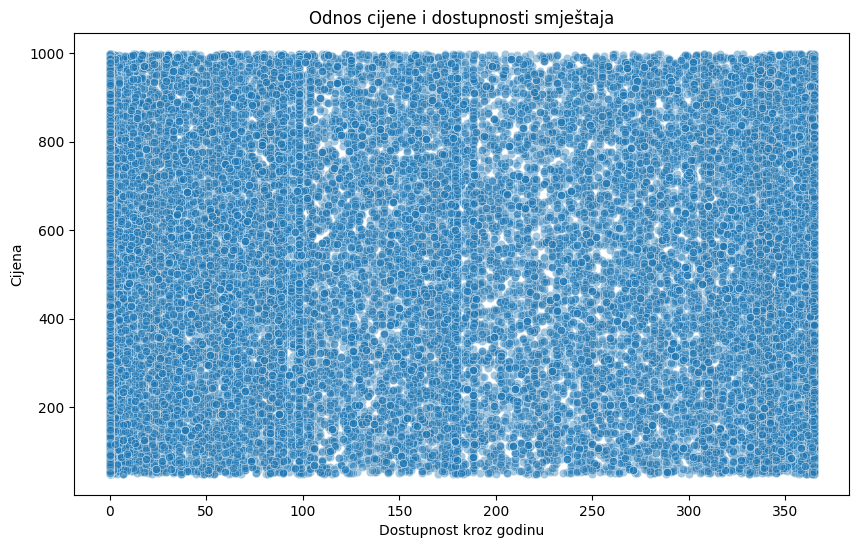

In [50]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x="availability_365",
    y="price",
    data=df,
    alpha=0.4
)

plt.title("Odnos cijene i dostupnosti smještaja")
plt.xlabel("Dostupnost kroz godinu")
plt.ylabel("Cijena")

plt.show()

Prikazan je odnos između cijene smještaja i njegove godišnje dostupnosti.

Analiza može ukazati na povezanost između cijene i popunjenosti smještaja.

## Korelacijska analiza numeričkih atributa

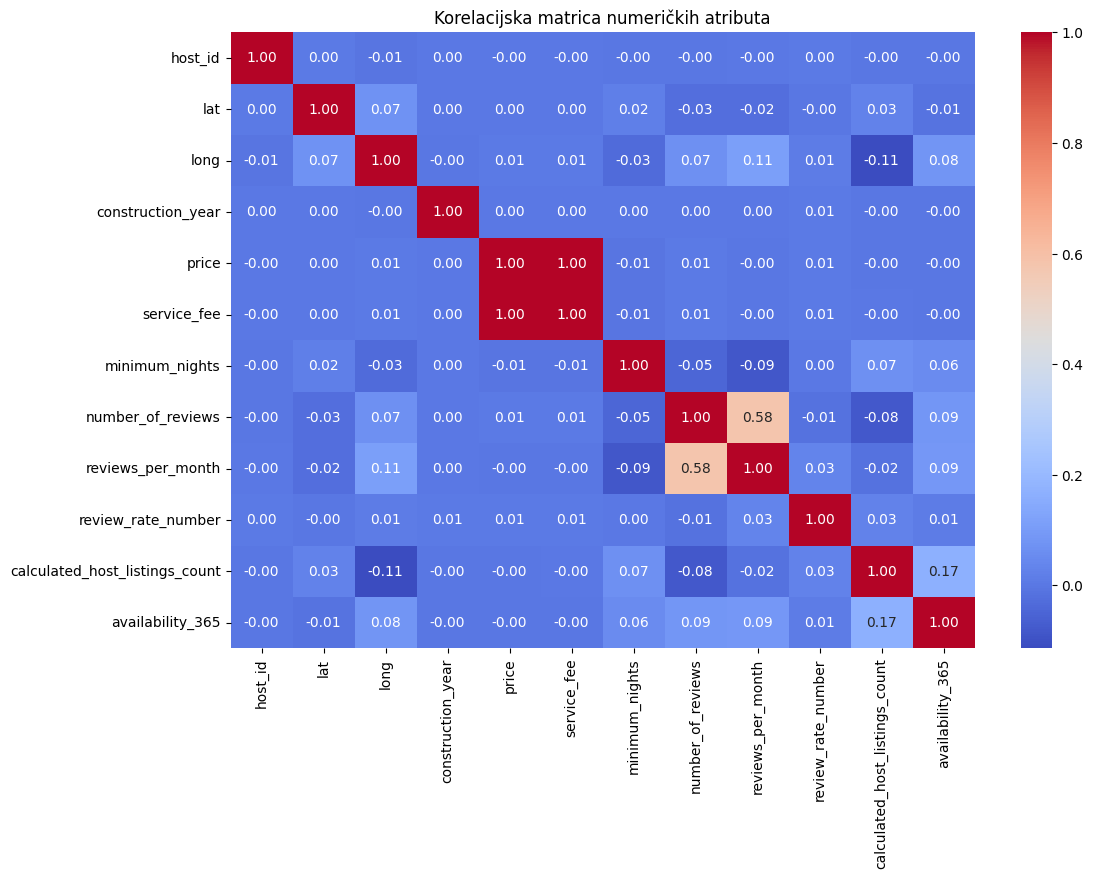

In [51]:
numeric_df = df.select_dtypes(include=["number"])

corr = numeric_df.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Korelacijska matrica numeričkih atributa")

plt.show()

Korelacijska matrica prikazuje jačinu i smjer povezanosti između numeričkih atributa.

Posebna pažnja posvećena je atributima povezanim s cijenom, recenzijama i dostupnošću jer će oni imati važnu ulogu u kasnijim fazama projekta.